# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [4]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [3]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [3]:
from sklearn.model_selection import train_test_split
X = data.drop('MEDV', axis=1)
y = data['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set percentage: {X_train.shape[0]/len(data)*100:.1f}%")
print(f"Testing set percentage: {X_test.shape[0]/len(data)*100:.1f}%")

Training set size: 404 samples
Testing set size: 102 samples
Training set percentage: 79.8%
Testing set percentage: 20.2%


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [4]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

print("Training set predictions (first 5):", y_train_pred[:5])
print("Training set actual values (first 5):", y_train[:5].values)
print("\nTesting set predictions (first 5):", y_test_pred[:5])
print("Testing set actual values (first 5):", y_test[:5].values)

print(f"\nModel coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Training set predictions (first 5): [10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]
Training set actual values (first 5): [12.  19.9 19.4 13.4 18.2]

Testing set predictions (first 5): [28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]
Testing set actual values (first 5): [23.6 32.4 13.6 22.8 16.1]

Model coefficients: [-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]
Model intercept: 30.246750993923442


## 3. Calculate and print R-squared for both the training and the testing set.

In [5]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R-squared (Training set): {r2_train:.4f}")
print(f"R-squared (Testing set): {r2_test:.4f}")

R-squared (Training set): 0.7509
R-squared (Testing set): 0.6688


## 4. Calculate and print mean squared error for both the training and the testing set.

In [6]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (Training set): {mse_train:.4f}")
print(f"Mean Squared Error (Testing set): {mse_test:.4f}")

Mean Squared Error (Training set): 21.6414
Mean Squared Error (Testing set): 24.2911


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [7]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Mean Absolute Error (Training set): {mae_train:.4f}")
print(f"Mean Absolute Error (Testing set): {mae_test:.4f}")

Mean Absolute Error (Training set): 3.3148
Mean Absolute Error (Testing set): 3.1891


## Classification Model Evaluation

In [8]:
from sklearn.datasets import load_iris
data = load_iris()

In [9]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [10]:
column_names = data.feature_names

In [11]:
df = pd.DataFrame(data['data'],columns=column_names)

In [17]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [12]:
target = pd.DataFrame(data.target)

In [13]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [14]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [15]:
from sklearn.model_selection import train_test_split

X = df  # The dataframe with the 4 features (sepal length, sepal width, petal length, petal width)
y = target  # The target variable (0=setosa, 1=versicolor, 2=virginica)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Total samples: {len(X)} samples")
print(f"\nTraining set percentage: {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Testing set percentage: {X_test.shape[0]/len(X)*100:.1f}%")

print("\nClass distribution in original dataset:")
print(y.value_counts().sort_index())

print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

print("\nClass distribution in testing set:")
print(y_test.value_counts().sort_index())

Training set size: 120 samples
Testing set size: 30 samples
Total samples: 150 samples

Training set percentage: 80.0%
Testing set percentage: 20.0%

Class distribution in original dataset:
0
0    50
1    50
2    50
Name: count, dtype: int64

Class distribution in training set:
0
0    40
1    40
2    40
Name: count, dtype: int64

Class distribution in testing set:
0
0    10
1    10
2    10
Name: count, dtype: int64


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [16]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(random_state=42, max_iter=200)
logreg_model.fit(X_train, y_train)
y_train_pred = logreg_model.predict(X_train)
y_test_pred = logreg_model.predict(X_test)

print("Training set predictions (first 10):", y_train_pred[:10])
print("Training set actual values (first 10):", y_train[:10].values.flatten())
print("\nTesting set predictions (first 10):", y_test_pred[:10])
print("Testing set actual values (first 10):", y_test[:10].values.flatten())

print(f"\nModel coefficients: {logreg_model.coef_}")
print(f"Model intercept: {logreg_model.intercept_}")
print(f"Number of iterations to converge: {logreg_model.n_iter_[0]}")

Training set predictions (first 10): [0 1 1 0 1 2 1 2 2 2]
Training set actual values (first 10): [0 2 1 0 1 2 1 2 2 2]

Testing set predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
Testing set actual values (first 10): [0 2 1 1 0 1 0 0 2 1]

Model coefficients: [[-5.29628828e-01  8.27369382e-01 -2.34725023e+00 -9.93472128e-01]
 [ 5.29729262e-01 -3.04883130e-01 -1.70966793e-01 -8.56168452e-01]
 [-1.00434720e-04 -5.22486252e-01  2.51821702e+00  1.84964058e+00]]
Model intercept: [ 10.12540323   1.798081   -11.92348423]
Number of iterations to converge: 72


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [17]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Accuracy (Training set): {acc_train:.4f}")
print(f"Accuracy (Testing set): {acc_test:.4f}")

# Accuracy = correct predictions / total predictions
# Good for balanced datasets like Iris (50 samples per class)

Accuracy (Training set): 0.9750
Accuracy (Testing set): 0.9667


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [18]:
from sklearn.metrics import balanced_accuracy_score

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy (Training set): {bal_acc_train:.4f}")
print(f"Balanced Accuracy (Testing set): {bal_acc_test:.4f}")

# Balanced accuracy averages the accuracy per class.
# More useful than regular accuracy when classes are imbalanced.
# For Iris (balanced) both scores should be very similar.

Balanced Accuracy (Training set): 0.9750
Balanced Accuracy (Testing set): 0.9667


## 10. Calculate and print the precision score for both the training and the testing set.

In [19]:
from sklearn.metrics import precision_score

prec_train = precision_score(y_train, y_train_pred, average='weighted')
prec_test = precision_score(y_test, y_test_pred, average='weighted')

print(f"Precision (Training set): {prec_train:.4f}")
print(f"Precision (Testing set): {prec_test:.4f}")

# Precision = of all predicted positives, how many were actually positive
# average='weighted' handles the 3 classes by weighting by class size

Precision (Training set): 0.9752
Precision (Testing set): 0.9697


## 11. Calculate and print the recall score for both the training and the testing set.

In [20]:
from sklearn.metrics import recall_score

rec_train = recall_score(y_train, y_train_pred, average='weighted')
rec_test = recall_score(y_test, y_test_pred, average='weighted')

print(f"Recall (Training set): {rec_train:.4f}")
print(f"Recall (Testing set): {rec_test:.4f}")

# Recall = of all actual positives, how many did the model catch
# High recall means few false negatives

Recall (Training set): 0.9750
Recall (Testing set): 0.9667


## 12. Calculate and print the F1 score for both the training and the testing set.

In [21]:
from sklearn.metrics import f1_score

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"F1 Score (Training set): {f1_train:.4f}")
print(f"F1 Score (Testing set): {f1_test:.4f}")

# F1 = harmonic mean of Precision and Recall
# Balances both metrics in a single number
# Useful when you care equally about precision and recall

F1 Score (Training set): 0.9750
F1 Score (Testing set): 0.9666


## 13. Generate confusion matrices for both the training and the testing set.

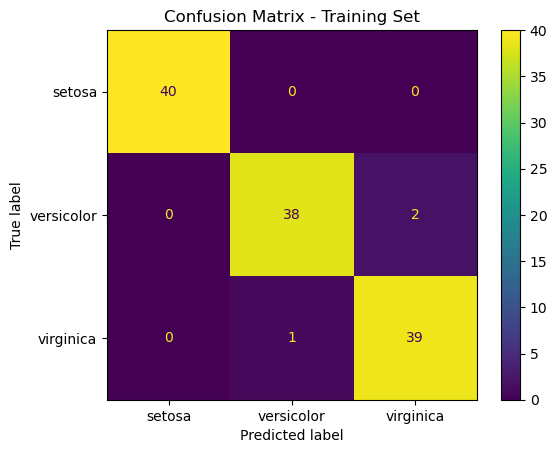

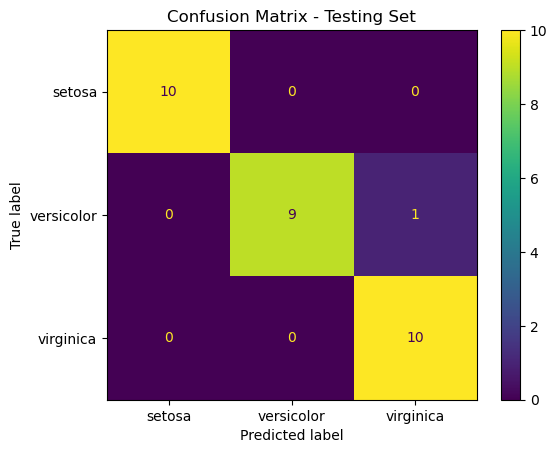

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Training set
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=data['target_names'])
disp_train.plot()
plt.title("Confusion Matrix - Training Set")
plt.show()

# Testing set
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=data['target_names'])
disp_test.plot()
plt.title("Confusion Matrix - Testing Set")
plt.show()

# Each row = actual class, each column = predicted class
# Diagonal = correct predictions
# Off-diagonal = errors (misclassifications)

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': logreg_model,
    'KNN': KNeighborsClassifier().fit(X_train, y_train),
    'Decision Tree': DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
}

for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"{name} → Accuracy: {accuracy_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Logistic Regression → Accuracy: 0.9667 | F1: 0.9666
KNN → Accuracy: 1.0000 | F1: 1.0000
Decision Tree → Accuracy: 0.9333 | F1: 0.9333
